- Adrián Marcelo Garza Morton 598817 & Patricio Dávila Santos 504056
- Inteligencia Artificial 2
- Final project: Sports Analytics using Deep Learning Models
- Dr. Andrés Hernández Gutiérrez
- 21/05/2026
- Universidad de Monterrey
- San Pedro Garza García, Nuevo León, México
- Damos nuestra palabra que hemos realizado esta actividad con integridad académica

En este notebook se implementa un pipeline inicial de detección de objetos para video aéreo de fútbol. El objetivo es detectar dos clases principales: jugadores y balón. Para esto se utiliza un modelo de detección basado en YOLOv8, un dataset etiquetado manualmente una preparación de datos, entrenamiento, validación, prueba, guardado del modelo e inferencia en frames no vistos.

Esta tarea se limita únicamente a detección y clasificación de objetos. Todavía no se implementa la parte de análisis deportivo, ya que en esta etapa el objetivo principal es demostrar que el pipeline técnico funciona correctamente.

Primero se instalan las librerías necesarias para trabajar con el pipeline. 'ultralytics' se utiliza para cargar, entrenar, validar y ejecutar inferencia con YOLOv8. 'opencv-python' permite leer el video y extraer frames. 'matplotlib' se usa para visualizar imágenes y resultados dentro del notebook. Finalmente, 'scikit-learn' se incluye como apoyo para posibles particiones o manipulación del dataset.

In [2]:
!pip install ultralytics opencv-python matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.0 MB/s eta 0:00:00


Importación de librerías para la manipulación de archivos y directorios (`os`, `shutil`, `random`), el procesamiento y visualización de imágenes (`cv2`, `matplotlib`), la gestión del modelo de detección (`YOLO`) y la partición del dataset (`train_test_split`)

In [3]:
import os
import cv2
import shutil
import random
import matplotlib.pyplot as plt

from ultralytics import YOLO
from sklearn.model_selection import train_test_split

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Se monta Google Drive para trabajar directamente con los archivos del proyecto. Esto permite acceder al video original, guardar los frames extraídos, cargar el dataset exportado desde Roboflow y respaldar los pesos del modelo entrenado. Usar Drive ayuda a evitar que los archivos se pierdan cuando se reinicia la sesión de Google Colab.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Preparación de datos: extracción de frames del video

Configuración de rutas en Google Drive y extracción de 430 frames distribuidos equitativamente a lo largo del video, evitando que se repitan los 195 frames que ya se tenían. En lugar de tomar frames consecutivos, los frames distribuidos nos permite obtener ejemplos de diferentes momentos del partido, con variación en la posición de los jugadores, la ubicación del balón y la distribución de los objetos en la cancha.

In [ ]:
# Carpeta principal en Google Drive
base_path = "/content/drive/MyDrive/IA2_Final_Project"

# Ruta del video
video_path = os.path.join(base_path, "2023_05_05_15_02_22-players-and-ball-detection.mp4")

# Carpeta donde se guardarán los nuevos frames
output_folder = os.path.join(base_path, "frames_nuevos_final")
os.makedirs(output_folder, exist_ok=True)

# Abrir video
cap = cv2.VideoCapture(video_path)

# Total de frames
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("Total de frames en el video:", total_frames)

# Frames que ya se habían extraído en la tarea 9
num_previous_frames = 200
previous_indices = [
    int(i * total_frames / num_previous_frames)
    for i in range(num_previous_frames)
]

# Queremos extraer frames nuevos
num_new_frames = 430

# Generamos más candidatos para poder saltarnos repetidos o cercanos
num_candidates = 1200
candidate_indices = [
    int(i * total_frames / num_candidates)
    for i in range(num_candidates)
]

# Distancia mínima respecto a frames anteriores
min_distance = 5

new_indices = []

for idx in candidate_indices:
    too_close = False

    for prev_idx in previous_indices:
        if abs(idx - prev_idx) <= min_distance:
            too_close = True
            break

    if not too_close:
        new_indices.append(idx)

    if len(new_indices) >= num_new_frames:
        break

count = 0

for frame_idx in new_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()

    if ret:
        frame_name = f"new_frame_{count:04d}.jpg"
        frame_path = os.path.join(output_folder, frame_name)
        cv2.imwrite(frame_path, frame)
        count += 1

cap.release()

print("Frames nuevos extraídos:", count)
print("Frames guardados en:", output_folder)

Total de frames en el video: 3846
Frames nuevos extraídos: 430
Frames guardados en: /content/drive/MyDrive/IA2_Final_Project/frames_nuevos_final


## Etiquetado de datos con Roboflow

Para el etiquetado de imágenes se utilizó Roboflow, una herramienta que permite crear datasets de detección de objetos mediante cajas delimitadoras. En Roboflow se subieron los frames extraídos del video y se etiquetaron manualmente los objetos de interés.

Las clases utilizadas fueron:
- `Ball`, que representa el balón.
- `Person`, que representa a los jugadores.

Aunque los nombres exportados por Roboflow aparecen como Ball y Person, estos corresponden directamente a las clases ball y player.

In [5]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 17.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


## Carga del dataset exportado desde Roboflow

Después de etiquetar las imágenes en Roboflow, el dataset fue exportado en formato YOLOv8 y guardado en Google Drive. En esta celda se define la ruta hacia la carpeta exportada y se revisa su contenido para confirmar que el dataset esté disponible dentro del notebook.

El formato YOLOv8 es compatible con Ultralytics y organiza los datos en carpetas de entrenamiento, validación y prueba, junto con un archivo data.yaml que indica las rutas y los nombres de las clases.

In [6]:
# Carpeta principal en Google Drive
base_path = "/content/drive/MyDrive/IA2_Final_Project"

# Ruta del video
video_path = os.path.join(base_path, "2023_05_05_15_02_22-players-and-ball-detection.mp4")

# Nueva carpeta del dataset exportado desde Roboflow
dataset_path = "/content/drive/MyDrive/IA2_Final_Project/My First Project.v2-2.yolov8"

# Revisar contenido de la carpeta
print(os.listdir(dataset_path))


['README.roboflow.txt', 'README.dataset.txt', 'data.yaml', 'test', 'train', 'valid']


Verificación de la estructura del dataset y lectura del `data.yaml` para confirmar la configuración de las clases.:


In [ ]:
# Archivo YAML del dataset
data_yaml = os.path.join(dataset_path, "data.yaml")

# Revisar contenido del dataset
print(os.listdir(dataset_path))

# Revisar contenido del YAML
with open(data_yaml, "r") as file:
    print(file.read())

['README.roboflow.txt', 'README.dataset.txt', 'data.yaml', 'test', 'train', 'valid']
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['Ball', 'Person']

roboflow:
  workspace: adrians-workspace-dwk1u
  project: my-first-project-tazwu
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/adrians-workspace-dwk1u/my-first-project-tazwu/dataset/2


## División del dataset

El dataset fue dividido en tres subconjuntos: entrenamiento, validación y prueba. La división se realizó desde Roboflow usando una proporción de 70% para entrenamiento, 20% para validación y 10% para prueba.

El conjunto de entrenamiento se utiliza para ajustar los pesos del modelo. El conjunto de validación permite monitorear el desempeño durante el entrenamiento. Finalmente, el conjunto de prueba se reserva para evaluar el modelo con imágenes que no fueron usadas para entrenar ni validar.

## Selección del modelo

Para esta tarea se seleccionó YOLOv8n, la versión nano de YOLOv8. Este modelo fue elegido porque ofrece una buena combinación entre velocidad, facilidad de implementación y rendimiento. Además, es adecuado para una primera implementación del pipeline, ya que permite entrenar y hacer inferencia de manera rápida en Google Colab.

El modelo se utiliza con pesos preentrenados, por lo que no se entrena desde cero. Esto corresponde a transferencia de aprendizaje, ya que se parte de un modelo previamente entrenado y se ajusta al dataset específico del proyecto. Esta decisión se basa en la investigación anterior, donde YOLOv8 fue identificado como la opción de preferencia por su rapidez y facilidad de uso.

## Entrenamiento del modelo

En esta sección se entrena el modelo YOLOv8n utilizando el dataset etiquetado. El entrenamiento se realiza con pesos preentrenados y se ajusta el modelo a las dos clases del proyecto: Ball y Person.

Los parámetros principales usados fueron:
- Modelo: YOLOv8n.
- Pesos preentrenados: sí.
- Número de épocas: 100.
- Tamaño de imagen: 640.
- Batch size: 8.
- Formato de dataset: YOLOv8.


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=data_yaml,
    epochs=100,
    imgsz=640,
    batch=8,
    device=0,
    name="final_soccer_yolov8n_player_ball"
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/IA2_Final_Project/My First Project.v2-2.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_soccer_yolov8n_player_ball, nbs=64, nms=False, op

Como se puede observar en los resultados del entrenamiento, el modelo logró completar las 100 épocas correctamente usando GPU. Las métricas muestran que el modelo aprendió a detectar los objetos del dataset, especialmente la clase Person, que obtuvo mejores resultados que la clase Ball. Esto era esperado, ya que los jugadores aparecen con mayor frecuencia y ocupan más espacio en la imagen, mientras que el balón es más pequeño y difícil de identificar en un video aéreo.

## Validación y prueba del modelo

Después del entrenamiento, se carga el mejor modelo guardado automáticamente por YOLOv8, conocido como best.pt. Este archivo contiene los pesos del modelo que obtuvo el mejor desempeño durante el entrenamiento.

Posteriormente, el modelo se evalúa sobre el conjunto de prueba. Este paso es importante porque permite medir el desempeño del modelo en imágenes que no fueron utilizadas durante el entrenamiento. En detección de objetos, las métricas principales no son solamente accuracy, sino también precision, recall, mAP50 y mAP50-95, ya que el modelo debe clasificar correctamente los objetos y también localizar sus cajas delimitadoras.

In [ ]:
import shutil

# Carpeta donde YOLO guardó el entrenamiento en Colab
run_folder = "/content/runs/detect/final_soccer_yolov8n_player_ball"

# Carpeta destino en Google Drive
drive_output_folder = "/content/drive/MyDrive/IA2_Final_Project/runs/final_soccer_yolov8n_player_ball"

# Copiar toda la carpeta del entrenamiento a Drive
shutil.copytree(run_folder, drive_output_folder, dirs_exist_ok=True)

print("Entrenamiento guardado en Drive:")
print(drive_output_folder)

Entrenamiento guardado en Drive:
/content/drive/MyDrive/IA2_Final_Project/runs/final_soccer_yolov8n_player_ball


In [ ]:
# Carpeta destino en Drive
weights_drive_folder = "/content/drive/MyDrive/IA2_Final_Project/modelo_entrenado"
os.makedirs(weights_drive_folder, exist_ok=True)

# Rutas de pesos
best_model = os.path.join(run_folder, "weights", "best.pt")
last_model = os.path.join(run_folder, "weights", "last.pt")

# Copiar a Drive
shutil.copy(best_model, os.path.join(weights_drive_folder, "best_final_soccer_yolov8n.pt"))
shutil.copy(last_model, os.path.join(weights_drive_folder, "last_final_soccer_yolov8n.pt"))

print("Modelos guardados en Drive.")

Modelos guardados en Drive.


In [7]:
best_model = YOLO("/content/drive/MyDrive/IA2_Final_Project/modelo_entrenado/best_final_soccer_yolov8n.pt")

## Evaluación en conjunto de prueba

Después del entrenamiento, se carga el mejor modelo guardado en Google Drive y se evalúa sobre el conjunto de prueba. Este conjunto no fue utilizado durante el entrenamiento, por lo que permite medir el desempeño del modelo en imágenes nuevas. Se reportan precision, recall y F1-score por clase.

In [ ]:
model_path = "/content/drive/MyDrive/IA2_Final_Project/modelo_entrenado/best_final_soccer_yolov8n.pt"
best_model = YOLO(model_path)

# Evaluar en el conjunto de prueba
metrics = best_model.val(
    data=data_yaml,
    split="test"
)

# Extraer precision y recall por clase
precision = metrics.box.p
recall = metrics.box.r

# Calcular F1-score por clase
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

# Mostrar resultados por clase
class_names = metrics.names

for i, class_name in class_names.items():
    print(f"Clase: {class_name}")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1-score: {f1[i]:.4f}")
    print()

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 0.0±0.0 MB/s, size: 46.5 KB)
val: Scanning /content/drive/MyDrive/IA2_Final_Project/My First Project.v2-2.yolov8/test/labels... 62 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 62/62 1.7s/it 1:44
val: New cache created: /content/drive/MyDrive/IA2_Final_Project/My First Project.v2-2.yolov8/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.0it/s 3.8s
                   all         62        808      0.592      0.697      0.606      0.372
                  Ball         60         60      0.428      0.462       0.32      0.198
                Person         62        748      0.756      0.932      0.892      0.546
Speed: 11.4ms preprocess, 11.8ms inference, 0.0ms loss, 6.2ms postprocess per ima

Como se puede observar en los resultados del conjunto de prueba, el modelo obtuvo un desempeño general aceptable para una primera versión del sistema. La clase Person tuvo mejores resultados, con una precisión de 0.7565, recall de 0.9318 y F1-score de 0.8350, lo que indica que el modelo logra detectar a la mayoría de los jugadores en los frames no vistos. En cambio, la clase Ball obtuvo una precisión de 0.4281, recall de 0.4616 y F1-score de 0.4442. Esto confirma que la detección del balón sigue siendo el reto principal, debido a que es un objeto pequeño, aparece con menos frecuencia y puede confundirse con líneas, sombras u otros elementos de la cancha.

# Definir cancha, media cancha y áreas de penal


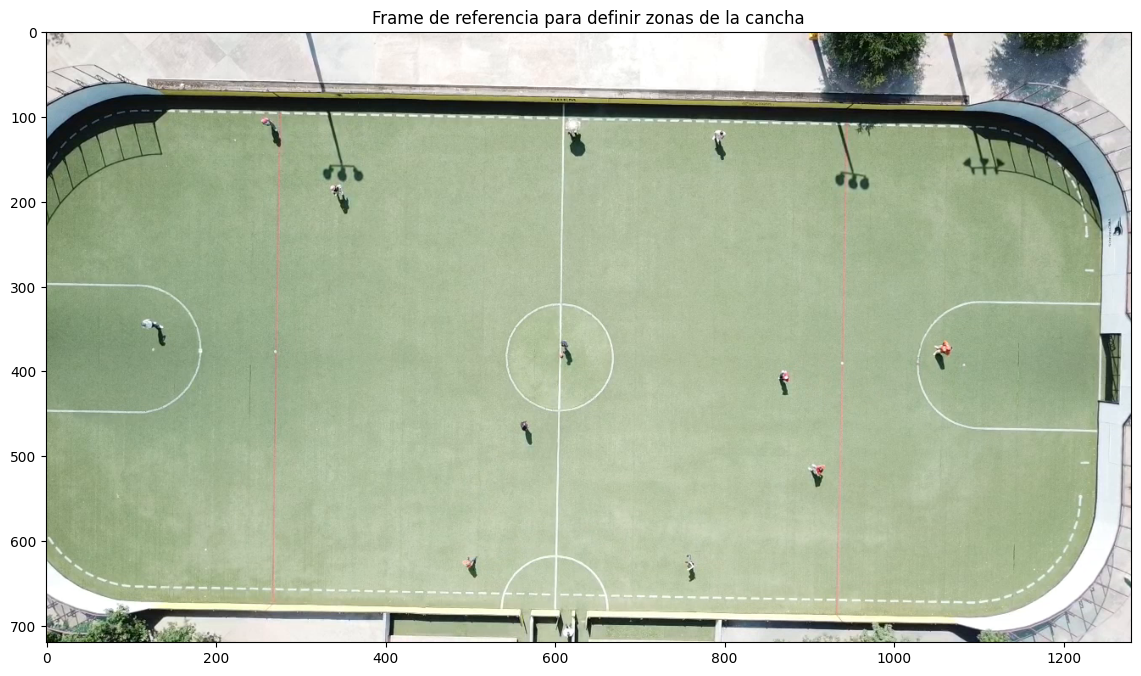

In [10]:
import cv2
import matplotlib.pyplot as plt

# Abrir video
cap = cv2.VideoCapture(video_path)

# Leer un frame de referencia
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)
ret, frame = cap.read()

cap.release()

# Convertir de BGR a RGB para mostrar correctamente con matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(frame_rgb)
plt.axis("on")
plt.title("Frame de referencia para definir zonas de la cancha")
plt.show()

In [79]:
import numpy as np

# Polígono aproximado de la cancha completa
court_polygon = np.array([
    [110, 90],    # parte superior izquierda
    [1135, 115],   # parte superior derecha
    [1175, 135],   # inicio curva superior derecha
    [1210, 165],
    [1230, 210],
    [1225, 520],
    [1220, 585],
    [1185, 630],
    [1150, 660],   # parte inferior derecha
    [1100, 670],
    [800, 665],
    [80, 655],    # parte inferior izquierda
    [45, 635],
    [7, 610],
    [2, 525],
    [2, 160],
    [20, 130],
    [30, 120],
    [40, 110]
], dtype=np.int32)

# Línea de media cancha aproximada
midline_x = 605

# Área de penal izquierda aproximada
left_penalty_polygon = np.array([
    [5, 290],
    [130, 290],
    [155, 305],
    [175, 330],
    [190, 360],
    [190, 390],
    [175, 420],
    [155, 445],
    [130, 455],
    [5, 455]
], dtype=np.int32)

# Área de penal derecha aproximada
right_penalty_polygon = np.array([
    [1240, 320],
    [1075, 320],
    [1050, 335],
    [1035, 360],
    [1025, 390],
    [1025, 420],
    [1055, 465],
    [1080, 470],
    [1240, 470]
], dtype=np.int32)

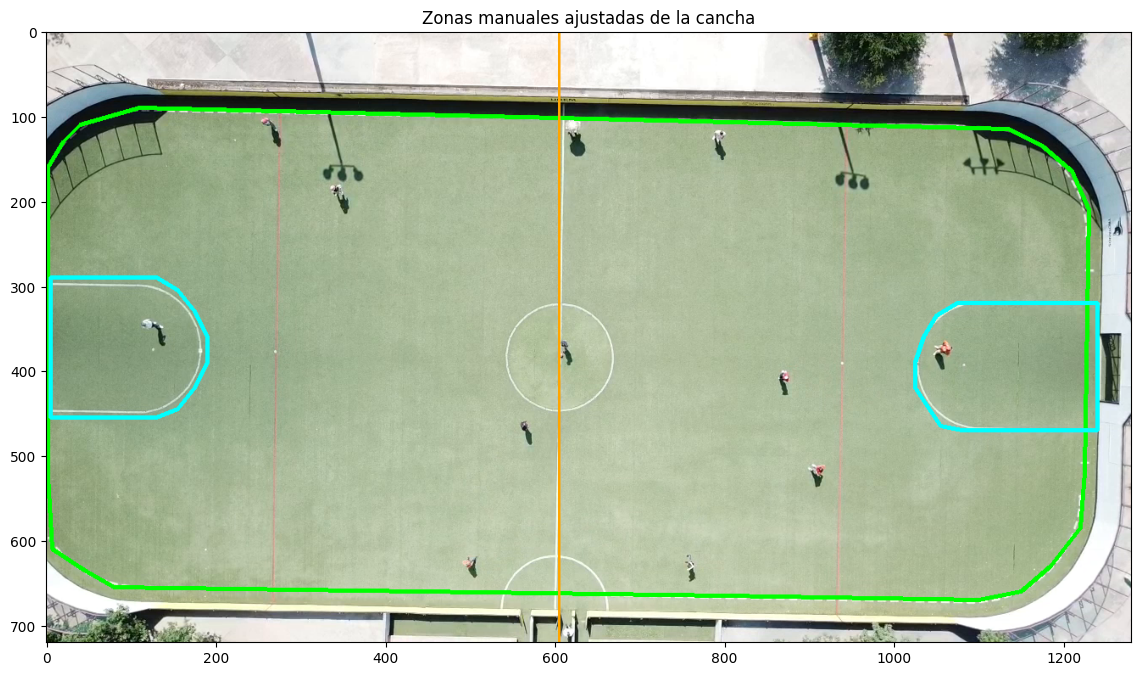

In [80]:
# Copiar frame para dibujar encima
frame_zones = frame.copy()

# Dibujar cancha
cv2.polylines(frame_zones, [court_polygon], True, (0, 255, 0), 3)

# Dibujar línea de media cancha
height = frame_zones.shape[0]
cv2.line(frame_zones, (midline_x, 0), (midline_x, height), (0, 165, 255), 2)

# Dibujar áreas de penal
cv2.polylines(frame_zones, [left_penalty_polygon], True, (255, 255, 0), 3)
cv2.polylines(frame_zones, [right_penalty_polygon], True, (255, 255, 0), 3)

# Mostrar resultado
frame_zones_rgb = cv2.cvtColor(frame_zones, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(frame_zones_rgb)
plt.axis("on")
plt.title("Zonas manuales ajustadas de la cancha")
plt.show()

Como se puede observar en el frame de referencia, las zonas principales de la cancha fueron delimitadas manualmente. El polígono verde representa los límites aproximados de la cancha siguiendo la línea blanca interior, la línea naranja divide el campo en lado izquierdo y derecho, y los polígonos color cyan representan las áreas de penal. Estas regiones se definieron una sola vez porque la cámara aérea permanece fija durante todo el video, por lo que pueden reutilizarse para calcular las analíticas visuales en cada frame.

## Cálculo de centroides y verificación de zonas

Para calcular las analíticas visuales, se utiliza el centroide de cada caja delimitadora detectada por el modelo. El centroide representa la posición aproximada del jugador o del balón dentro del frame. A partir de ese punto, se verifica si el objeto está dentro de la cancha, en el lado izquierdo o derecho, dentro de alguna área de penal o fuera del campo.

In [81]:
import cv2

# Función para calcular el centroide de una caja delimitadora
def get_centroid(x1, y1, x2, y2):
    cx = int((x1 + x2) / 2)
    cy = int((y1 + y2) / 2)
    return cx, cy

# Función para verificar si un punto está dentro de un polígono
def point_inside_polygon(point, polygon):
    result = cv2.pointPolygonTest(polygon, point, False)
    return result >= 0

## Cálculo de analíticas visuales por frame

En esta sección se define una función que recibe las detecciones generadas por el modelo en un frame y calcula las analíticas solicitadas. Para cada jugador detectado, se revisa si su centroide está dentro de la cancha, en el lado izquierdo, en el lado derecho o dentro de alguna de las áreas de penal. Para el balón, se indica si fue detectado en el lado izquierdo, en el lado derecho o fuera de la cancha.

In [85]:
def compute_frame_analytics(detections):
    left_players = 0
    right_players = 0
    outside_players = 0
    left_penalty_players = 0
    right_penalty_players = 0
    ball_position = "Ball detected: No"

    for det in detections:
        class_name = det["class_name"]
        cx = det["cx"]
        cy = det["cy"]

        inside_court = point_inside_polygon((cx, cy), court_polygon)

        # Analítica para jugadores
        if class_name.lower() in ["person", "player"]:
            if inside_court:
                if cx < midline_x:
                    left_players += 1
                else:
                    right_players += 1

                if point_inside_polygon((cx, cy), left_penalty_polygon):
                    left_penalty_players += 1

                if point_inside_polygon((cx, cy), right_penalty_polygon):
                    right_penalty_players += 1
            else:
                outside_players += 1

        # Analítica para balón
        elif class_name.lower() in ["ball"]:
          if inside_court:
            if cx < midline_x:
              ball_position = "Ball detected: Left"
            else:
              ball_position = "Ball detected: Right"
          else:
            ball_position = "Ball detected: Out"

    return {
        "left_players": left_players,
        "right_players": right_players,
        "inside_players": left_players + right_players,
        "outside_players": outside_players,
        "left_penalty_players": left_penalty_players,
        "right_penalty_players": right_penalty_players,
        "ball_position": ball_position
    }

## Visualización de analíticas en el frame

Después de calcular las analíticas, se dibujan sobre el frame como texto. También se muestran las zonas manuales de la cancha para facilitar la interpretación visual del resultado. Esto permite que el video final incluya tanto las detecciones del modelo como la información de análisis deportivo solicitada.

In [90]:
def draw_analytics(frame, analytics):
    # Fondo blanco para mejorar la lectura del texto
    cv2.rectangle(frame, (420, 5), (780, 95), (255, 255, 255), -1)

    cv2.putText(frame, "Visual Analytics", (565, 22),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1)

    cv2.putText(frame, f"Left side: {analytics['left_players']} players", (455, 42),
                cv2.FONT_HERSHEY_SIMPLEX, 0.36, (0, 0, 0), 1)

    cv2.putText(frame, f"Right side: {analytics['right_players']} players", (455, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.36, (0, 0, 0), 1)

    cv2.putText(frame, analytics["ball_position"], (455, 78),
                cv2.FONT_HERSHEY_SIMPLEX, 0.36, (0, 0, 0), 1)

    cv2.putText(frame, f"Players in: {analytics['inside_players']}", (650, 42),
                cv2.FONT_HERSHEY_SIMPLEX, 0.36, (0, 0, 0), 1)

    cv2.putText(frame, f"Left penalty: {analytics['left_penalty_players']}", (650, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.36, (0, 0, 0), 1)

    cv2.putText(frame, f"Right penalty: {analytics['right_penalty_players']}", (650, 78),
                cv2.FONT_HERSHEY_SIMPLEX, 0.36, (0, 0, 0), 1)

    cv2.putText(frame, f"Outside court: {analytics['outside_players']}", (650, 90),
                cv2.FONT_HERSHEY_SIMPLEX, 0.36, (0, 0, 0), 1)

    return frame

## Prueba del pipeline sobre un segmento corto del video

Antes de procesar la secuencia completa, se realiza una prueba con una cantidad limitada de frames. Esto permite verificar que el modelo se cargue correctamente, que las detecciones se dibujen en el frame, que las zonas manuales aparezcan bien y que las analíticas visuales se calculen correctamente.

In [91]:
from ultralytics import YOLO
import cv2
import os

# Ruta del video original
video_path = "/content/drive/MyDrive/IA2_Final_Project/2023_05_05_15_02_22-players-and-ball-detection.mp4"

# Ruta del modelo entrenado guardado en Drive
model_path = "/content/drive/MyDrive/IA2_Final_Project/modelo_entrenado/best_final_soccer_yolov8n.pt"

# Ruta del video de prueba
output_video_path = "/content/drive/MyDrive/IA2_Final_Project/test_output_analytics.mp4"

# Cargar modelo
model = YOLO(model_path)

# Abrir video
cap = cv2.VideoCapture(video_path)

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Crear video de salida
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

frame_count = 0
max_frames = 100

while frame_count < max_frames:
    ret, frame = cap.read()

    if not ret:
        break

    results = model.predict(frame, conf=0.25, verbose=False)

    detections = []

    for result in results:
        boxes = result.boxes

        for box in boxes:
            cls_id = int(box.cls[0])
            class_name = model.names[cls_id]
            conf = float(box.conf[0])

            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

            cx, cy = get_centroid(x1, y1, x2, y2)

            detections.append({
                "class_name": class_name,
                "confidence": conf,
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "cx": cx,
                "cy": cy
            })

            # Color según clase
            if class_name.lower() in ["person", "player"]:
                color = (0, 0, 255)  # rojo para jugadores
            else:
                color = (255, 0, 0)  # azul para balón

            # Dibujar caja, centroide y etiqueta
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.circle(frame, (cx, cy), 3, color, -1)
            cv2.putText(frame, f"{class_name} {conf:.2f}", (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 2)

    # Dibujar zonas manuales
    cv2.polylines(frame, [court_polygon], True, (0, 255, 0), 2)
    cv2.line(frame, (midline_x, 0), (midline_x, height), (0, 165, 255), 2)
    cv2.polylines(frame, [left_penalty_polygon], True, (255, 255, 0), 2)
    cv2.polylines(frame, [right_penalty_polygon], True, (255, 255, 0), 2)

    # Calcular analíticas
    analytics = compute_frame_analytics(detections)

    # Dibujar analíticas
    frame = draw_analytics(frame, analytics)

    # Guardar frame en video
    out.write(frame)

    frame_count += 1

cap.release()
out.release()

print("Video de prueba guardado en:", output_video_path)

Video de prueba guardado en: /content/drive/MyDrive/IA2_Final_Project/test_output_analytics.mp4


## Procesamiento del video completo

Después de verificar el pipeline con un segmento corto, se procesa la secuencia completa del video. Para cada frame, el modelo YOLOv8 detecta jugadores y balón, se calcula el centroide de cada caja delimitadora y se generan las analíticas visuales correspondientes. Finalmente, cada frame procesado se guarda en un nuevo archivo MP4 que incluye las detecciones, las zonas manuales de la cancha y el texto de analítica visual.

In [96]:
from ultralytics import YOLO
import cv2
import os

# Ruta del video original
video_path = "/content/drive/MyDrive/IA2_Final_Project/2023_05_05_15_02_22-players-and-ball-detection.mp4"

# Ruta del modelo entrenado guardado en Drive
model_path = "/content/drive/MyDrive/IA2_Final_Project/modelo_entrenado/best_final_soccer_yolov8n.pt"

# Ruta del video final de salida
output_video_path = "/content/drive/MyDrive/IA2_Final_Project/final_output_analytics.mp4"

# Cargar modelo entrenado
model = YOLO(model_path)

# Abrir video original
cap = cv2.VideoCapture(video_path)

# Obtener propiedades del video
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Resolución:", width, "x", height)
print("Total de frames:", total_frames)

# Crear video de salida
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

frame_count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # Ejecutar inferencia en el frame actual
    results = model.predict(frame, conf=0.05, verbose=False)

    detections = []

    for result in results:
        boxes = result.boxes

        for box in boxes:
            cls_id = int(box.cls[0])
            class_name = model.names[cls_id]
            conf = float(box.conf[0])

            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

            box_width = x2 - x1
            box_height = y2 - y1
            box_area = box_width * box_height

            # Filtro por clase:
            # Para Person se exige mayor confianza.
            # Para Ball menor confianza.
            if class_name.lower() in ["person", "player"]:
              if conf < 0.25:
                continue

              # Filtrar cajas demasiado grandes para personas
              if box_width > 80 or box_height > 120 or box_area > 7000:
                continue

            # Filtrar detecciones falsas del balón
            elif class_name.lower() == "ball":
              if conf < 0.05:
                continue

              # Filtrar cajas demasiado grandes para balon
              if box_area > 2500:
                continue

            cx, cy = get_centroid(x1, y1, x2, y2)

            detections.append({
                "class_name": class_name,
                "confidence": conf,
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "cx": cx,
                "cy": cy
            })

            # Color según clase
            if class_name.lower() in ["person", "player"]:
                color = (0, 0, 255)  # rojo para jugadores
            else:
                color = (255, 0, 0)  # azul para balón

            # Dibujar caja delimitadora, centroide y etiqueta
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.circle(frame, (cx, cy), 3, color, -1)
            cv2.putText(frame, f"{class_name} {conf:.2f}", (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.36, color, 2)

    # Dibujar zonas manuales de la cancha
    cv2.polylines(frame, [court_polygon], True, (0, 255, 0), 2)
    cv2.line(frame, (midline_x, 0), (midline_x, height), (0, 165, 255), 2)
    cv2.polylines(frame, [left_penalty_polygon], True, (255, 255, 0), 2)
    cv2.polylines(frame, [right_penalty_polygon], True, (255, 255, 0), 2)

    # Calcular analíticas visuales
    analytics = compute_frame_analytics(detections)

    # Dibujar analíticas visuales sobre el frame
    frame = draw_analytics(frame, analytics)

    # Guardar frame procesado en el video de salida
    out.write(frame)

    frame_count += 1

    if frame_count % 500 == 0:
        print("Frames procesados:", frame_count, "/", total_frames)

cap.release()
out.release()

print("Video final guardado en:", output_video_path)

FPS: 30
Resolución: 1280 x 720
Total de frames: 3846
Frames procesados: 500 / 3846
Frames procesados: 1000 / 3846
Frames procesados: 1500 / 3846
Frames procesados: 2000 / 3846
Frames procesados: 2500 / 3846
Frames procesados: 3000 / 3846
Frames procesados: 3500 / 3846
Video final guardado en: /content/drive/MyDrive/IA2_Final_Project/final_output_analytics.mp4


Durante la inferencia se utilizaron umbrales de confianza diferentes por clase. Para la clase Person se mantuvo un umbral más alto (0.25), ya que los jugadores son objetos más grandes y el modelo los detecta con mayor seguridad. Para la clase Ball se permitió un umbral menor (0.05), ya que el balón es un objeto pequeño y muchas detecciones correctas aparecen con menor confianza. Para evitar falsos positivos, se agregaron filtros por tamaño de caja, ya que el balón no debería ocupar una región grande dentro del frame.

## Resultado final del procesamiento del video

El video completo fue procesado frame por frame utilizando el modelo YOLOv8 entrenado. En cada frame se detectaron jugadores y balón, se calcularon los centroides de las cajas delimitadoras y se compararon con las zonas manuales de la cancha. Se generaron analíticas visuales como el número de jugadores en cada lado de la cancha, jugadores dentro de las áreas de penal, jugadores fuera del campo y ubicación del balón.

El resultado final se guardó como un archivo MP4 que muestra las detecciones, las zonas de la cancha y las analíticas visuales sobre el video original. Aunque la detección de jugadores fue más estable que la del balón, el sistema logra demostrar el flujo completo.

## Explicación de los resultados

Después de entrenar el modelo YOLOv8n con el dataset ampliado, los resultados mejoraron respecto a la implementación inicial de la Tarea 9. En el conjunto de prueba, el modelo obtuvo mejores métricas para la clase Person que para la clase Ball. Esto era esperado, ya que los jugadores son objetos más grandes, aparecen con mayor frecuencia y son más fáciles de distinguir desde la vista aérea. En cambio, el balón sigue siendo el objeto más difícil porque ocupa pocos píxeles, se mueve rápidamente y puede confundirse con líneas, sombras o elementos de la cancha.

En el video final se observa que el modelo detecta a la mayoría de los jugadores de manera estable y permite calcular correctamente las analíticas visuales, como el número de jugadores por lado de la cancha, jugadores dentro de las áreas de penal y jugadores fuera del campo. Para el balón, la detección no es constante durante todo el video, pero sí aparece correctamente en varios momentos. Para mejorar esta parte, se utilizaron umbrales de confianza diferentes por clase: un umbral más alto para Person y uno más bajo para Ball, además de filtros por tamaño de caja para evitar detecciones falsas muy grandes. Con esto, el video final muestra un resultado más limpio y funcional.

## Conclusión

En este proyecto se desarrolló un pipeline completo de visión por computadora para análisis deportivo en video aéreo de fútbol. Se utilizó YOLOv8n con transferencia de aprendizaje para detectar dos clases principales: Person y Ball. A partir de las detecciones, se calcularon centroides y se compararon con zonas de la cancha definidas manualmente para generar analíticas visuales por frame.

El resultado final fue un video MP4 donde se muestran las detecciones de jugadores y balón, junto con información como jugadores en cada lado de la cancha, jugadores dentro de las áreas de penal, jugadores fuera del campo y ubicación del balón. El sistema tuvo mejor desempeño detectando jugadores que detectando el balón, lo cual se debe principalmente al tamaño reducido del balón y a la dificultad de identificarlo desde una vista aérea. El proyecto cumplió correctamente con nuestros objetivos.

## Limitaciones y mejoras propuestas

Una de las principales limitaciones del modelo es la detección del balón, ya que es un objeto pequeño, aparece con menos frecuencia en el dataset y puede confundirse con otros elementos de la cancha. Además, el dataset utilizado podría ser más grande aún para asegurar una detección constante. El modelo puede no generalizar bien a otros videos o condiciones de iluminación. Como mejora, se propone agregar más frames etiquetados, especialmente con ejemplos claros del balón, aumentar la cantidad de datos de entrenamiento y probar una resolución mayor o técnicas enfocadas en objetos pequeños para mejorar la precisión del detector.

## Hallazgo Adicional


Nos dimos cuenta que al empezar el proceso de entrenamiento mediantes épocas, la cantidad de tiempo por cada una de ellas era enorme, consideramos cambiar de CPU a GPU como un intento en el que estábamos muy semi-confiados, para nuestra sorpresa el cambio incrementó la velocidad de manera increíble; De completar una época en 2:30 minutos, el programa pasaba una cada una en 8 segundos.

 Investigando como complemento a nuestra actividad encontramos que: Las épocas en una red neuronal se entrenan mucho más rápido con una GPU porque el entrenamiento consiste principalmente en hacer enormes cantidades de operaciones matemáticas repetitivas, como multiplicaciones de matrices, y las GPUs están diseñadas para ejecutar miles de esas operaciones en paralelo al mismo tiempo, mientras que una CPU tiene pocos núcleos optimizados para tareas más generales y secuenciales; por eso, durante el entrenamiento de modelos grandes, una GPU puede procesar los cálculos de la red neuronal muchísimo más rápido que una CPU.

CPU:  Ryzen 7 7700X, GPU:RTX 5070
